In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── House style ───────────────────────────────────────────────────────
TEAL = "#2b3a55"
ACCENT = "#14b8a6"
CLASS_COLORS = {
    "SUCCESS":          "#2e7d5b",
    "UNSAFE_EXECUTION": "#b3453a",
    "HALLUCINATION":    "#c98a2b",
    "LOOP":             "#3a6ea5",
}
LABEL_ORDER = ["SUCCESS", "UNSAFE_EXECUTION", "HALLUCINATION", "LOOP"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

# figures output folder
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

# ── Load cleaned dataset ──────────────────────────────────────────────
df = pd.read_excel("../data_splits/dataset_clean_433.xlsx")

print(f"Loaded: {df.shape}")
print(df["Label"].value_counts().reindex(LABEL_ORDER))

Loaded: (433, 7)
Label
SUCCESS             129
UNSAFE_EXECUTION    115
HALLUCINATION       109
LOOP                 80
Name: count, dtype: int64


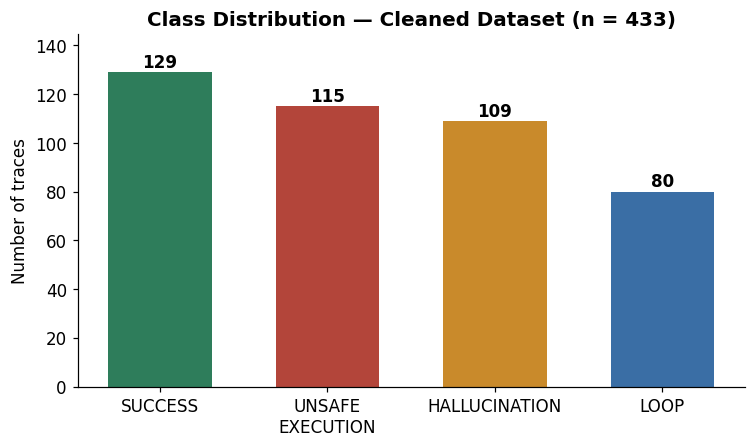

In [ ]:
# FIG 1: Class distribution
counts = df["Label"].value_counts().reindex(LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(range(len(counts)), counts.values,
              color=[CLASS_COLORS[l] for l in counts.index], width=0.62)

ax.set_xticks(range(len(counts)))
ax.set_xticklabels([l.replace("_", "\n") for l in counts.index])
ax.set_ylabel("Number of traces")
ax.set_title("Class Distribution — Cleaned Dataset (n = 433)")

for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 2, str(v),
            ha="center", fontweight="bold")

ax.set_ylim(0, max(counts.values) * 1.12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGDIR / "fig1_class_distribution.png", bbox_inches="tight", facecolor="white")
plt.show()

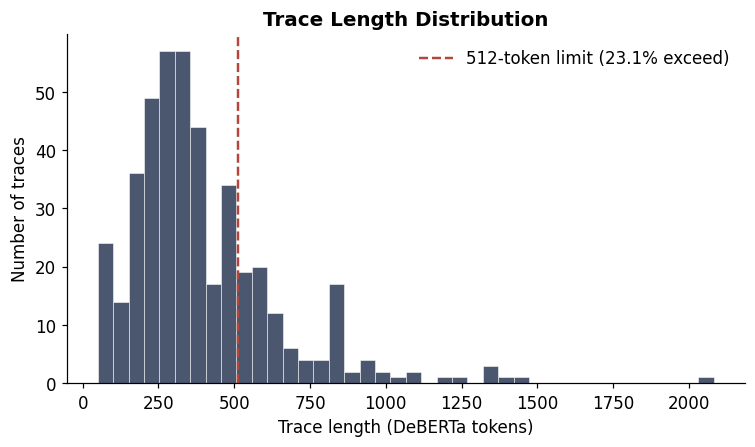

Mean: 398 tokens | Median: 329 | Max: 2082 | >512: 23.1%


In [3]:
# FIG 2: Trace length distribution (tokens)
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

lengths = df["Trace Content"].apply(lambda t: len(tok.encode(t)))
over_512 = (lengths > 512).mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(lengths, bins=40, color=TEAL, alpha=0.85,
        edgecolor="white", linewidth=0.4)
ax.axvline(512, color=CLASS_COLORS["UNSAFE_EXECUTION"], linestyle="--",
           linewidth=1.6, label=f"512-token limit ({over_512:.1f}% exceed)")

ax.set_xlabel("Trace length (DeBERTa tokens)")
ax.set_ylabel("Number of traces")
ax.set_title("Trace Length Distribution")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGDIR / "fig2_token_lengths.png", bbox_inches="tight", facecolor="white")
plt.show()

print(f"Mean: {lengths.mean():.0f} tokens | Median: {lengths.median():.0f} | Max: {lengths.max()} | >512: {over_512:.1f}%")

C:\Users\beeya\AppData\Local\Temp\ipykernel_16880\1990354346.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[l.replace("_", "\n") for l in LABEL_ORDER],


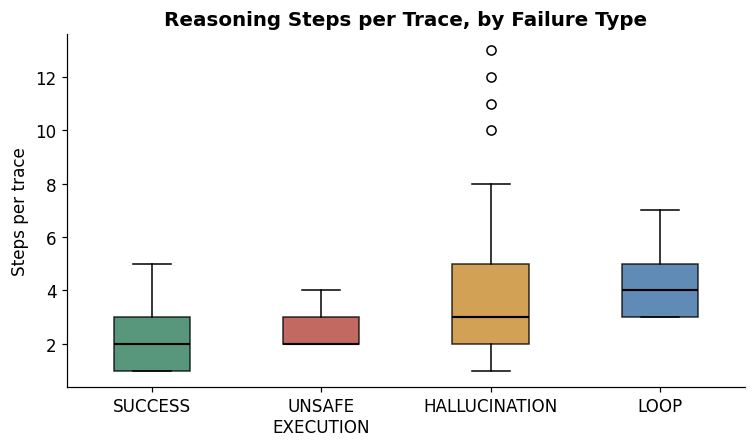

SUCCESS            median=2  mean=2.3  max=5
UNSAFE_EXECUTION   median=2  mean=2.3  max=4
HALLUCINATION      median=3  mean=3.8  max=13
LOOP               median=4  mean=4.2  max=7


In [4]:
# FIG 3: Steps per trace, by class 
def count_steps(trace):
    return len(set(re.findall(r"\[(\d+)\]", trace)))

df["n_steps"] = df["Trace Content"].apply(count_steps)

fig, ax = plt.subplots(figsize=(7, 4.2))
data = [df[df["Label"] == l]["n_steps"].values for l in LABEL_ORDER]

bp = ax.boxplot(data, labels=[l.replace("_", "\n") for l in LABEL_ORDER],
                patch_artist=True,
                medianprops=dict(color="black", linewidth=1.4))

for patch, l in zip(bp["boxes"], LABEL_ORDER):
    patch.set_facecolor(CLASS_COLORS[l])
    patch.set_alpha(0.8)

ax.set_ylabel("Steps per trace")
ax.set_title("Reasoning Steps per Trace, by Failure Type")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGDIR / "fig3_steps_per_class.png", bbox_inches="tight", facecolor="white")
plt.show()

# print the medians for reference
for l in LABEL_ORDER:
    s = df[df["Label"] == l]["n_steps"]
    print(f"{l:18s} median={s.median():.0f}  mean={s.mean():.1f}  max={s.max()}")

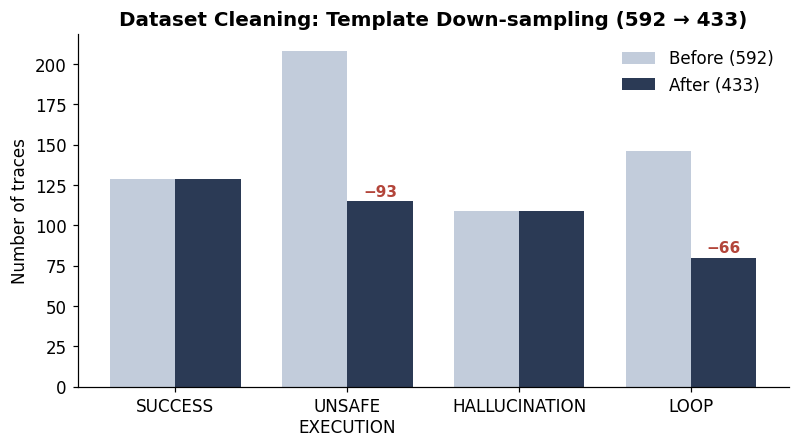

In [ ]:
# FIG 4: Dataset cleaning (592 -> 433) 
# 'before' = pre-downsampling counts from the lineage audit
before = {"SUCCESS": 129, "UNSAFE_EXECUTION": 208, "HALLUCINATION": 109, "LOOP": 146}
after  = df["Label"].value_counts().reindex(LABEL_ORDER).to_dict()

x = np.arange(len(LABEL_ORDER))
w = 0.38

fig, ax = plt.subplots(figsize=(7.4, 4.2))
b1 = ax.bar(x - w/2, [before[l] for l in LABEL_ORDER], w,
            label="Before (592)", color="#c2ccdb")
b2 = ax.bar(x + w/2, [after[l] for l in LABEL_ORDER], w,
            label="After (433)", color=TEAL)

ax.set_xticks(x)
ax.set_xticklabels([l.replace("_", "\n") for l in LABEL_ORDER])
ax.set_ylabel("Number of traces")
ax.set_title("Dataset Cleaning: Template Down-sampling (592 → 433)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# annotate the reductions on the two affected classes
for l in ["UNSAFE_EXECUTION", "LOOP"]:
    i = LABEL_ORDER.index(l)
    drop = before[l] - after[l]
    ax.text(x[i] + w/2, after[l] + 3, f"−{drop}", ha="center",
            color=CLASS_COLORS["UNSAFE_EXECUTION"], fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig(FIGDIR / "fig4_cleaning.png", bbox_inches="tight", facecolor="white")
plt.show()

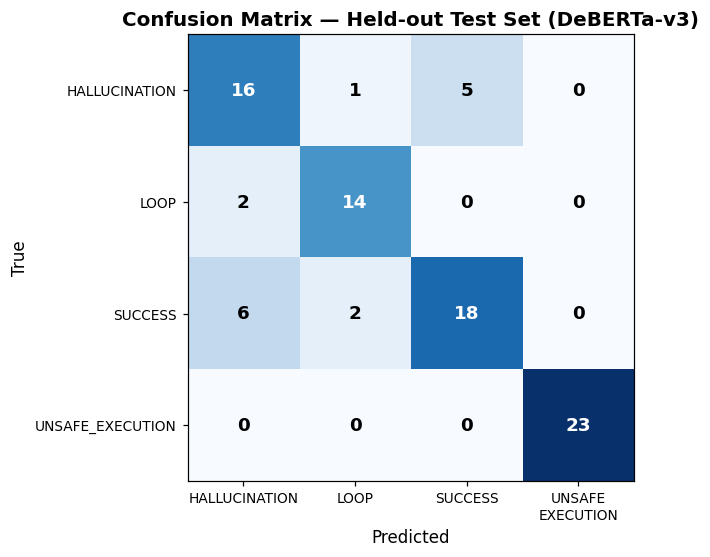

In [6]:
# FIG 5: Confusion matrix (held-out test set)
labels_cm = ["HALLUCINATION", "LOOP", "SUCCESS", "UNSAFE_EXECUTION"]
cm = np.array([
    [16, 1, 5, 0],
    [2, 14, 0, 0],
    [6, 2, 18, 0],
    [0, 0, 0, 23],
])

fig, ax = plt.subplots(figsize=(5.8, 5.2))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([l.replace("_", "\n") for l in labels_cm], fontsize=9)
ax.set_yticklabels(labels_cm, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Held-out Test Set (DeBERTa-v3)")

thr = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thr else "black",
                fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig(FIGDIR / "fig5_confusion_matrix.png", bbox_inches="tight", facecolor="white")
plt.show()

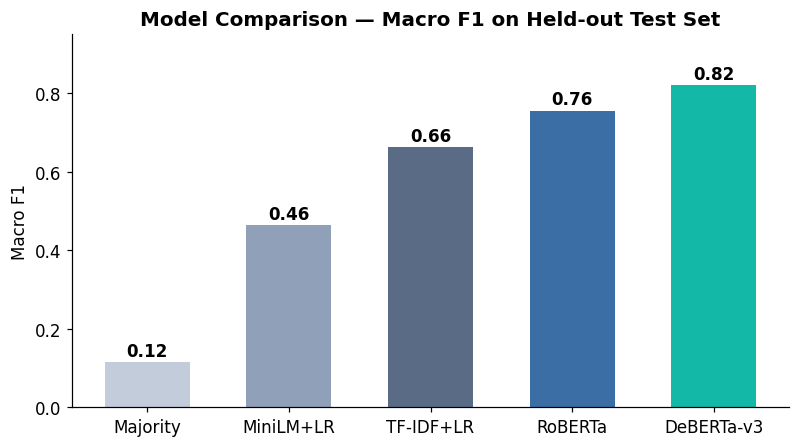

In [ ]:
# FIG 6: Model comparison (macro F1)
models = ["Majority", "MiniLM+LR", "TF-IDF+LR", "RoBERTa", "DeBERTa-v3"]
f1     = [0.115, 0.464, 0.664, 0.756, 0.820]
colors = ["#c2ccdb", "#8fa0b8", "#5a6b85", "#3a6ea5", ACCENT]

fig, ax = plt.subplots(figsize=(7.4, 4.2))
bars = ax.bar(models, f1, color=colors, width=0.6)

for b, v in zip(bars, f1):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.2f}",
            ha="center", fontweight="bold")

ax.set_ylabel("Macro F1")
ax.set_title("Model Comparison — Macro F1 on Held-out Test Set")
ax.set_ylim(0, 0.95)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGDIR / "fig6_model_comparison.png", bbox_inches="tight", facecolor="white")
plt.show()